In [14]:
import numpy as np
from embedding import Tokenizer, Word2Vec

import matplotlib.pyplot as plt

## Word2Vec Implementation

Here you can find a demonstration of training a word2vec skip-gram version and some analysis of the results.

In [9]:
# helper functions
def split_file(input_file, train_filename, val_filename, train_lines_amount):
    with (open(input_file, 'r', encoding='utf-8') as input,
          open(train_filename, 'w', encoding='utf-8') as output_train,
          open(val_filename, 'w', encoding='utf-8') as output_val):
        for i, line in enumerate(input):
            if i < train_lines_amount:
                output_train.write(line)
            else:
                output_val.write(line)

def viz_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 4))
    plt.plot(epochs, train_losses, label="train loss", lw=2, marker='o')
    plt.plot(epochs, val_losses, label="validation loss", lw=2, marker='o')
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def cosine_similarity(first_embedding, second_embedding):
    return first_embedding @ second_embedding / (np.linalg.norm(first_embedding) * np.linalg.norm(second_embedding))

raw_data = "data/wiki.txt"

I used wikipedia articles as text corpus, let's download and prepare it:

In [4]:
!gdown "https://drive.google.com/uc?id=1YnTE3QnU0jI0omV-Bg3OKXs2IWKJ8a34" -O {raw_data}

Downloading...
From (original): https://drive.google.com/uc?id=1YnTE3QnU0jI0omV-Bg3OKXs2IWKJ8a34
From (redirected): https://drive.google.com/uc?id=1YnTE3QnU0jI0omV-Bg3OKXs2IWKJ8a34&confirm=t&uuid=09eddf36-d36b-4bb8-8b7b-1403ab2571de
To: /Users/dariakay/edu/word2vec/data/wiki.txt
100%|████████████████████████████████████████| 179M/179M [00:05<00:00, 35.7MB/s]


In [6]:
# limit the amount of the processed text since the training process take a lot of time
sentences_count = 10_000
train_size = int(0.9 * sentences_count)

processed_data = "data/wiki_dataset.txt"
train_data = "data/train_data.txt"
val_data = "data/val_data.txt"

tokenizer = Tokenizer()
tokenizer.fit(raw_data, processed_data, sentences_count=sentences_count)

split_file(processed_data, train_data, val_data, train_size)

Vocab len: 12035


Train word2vec:

epoch:   0%|          | 0/20 [00:00<?, ?it/s]

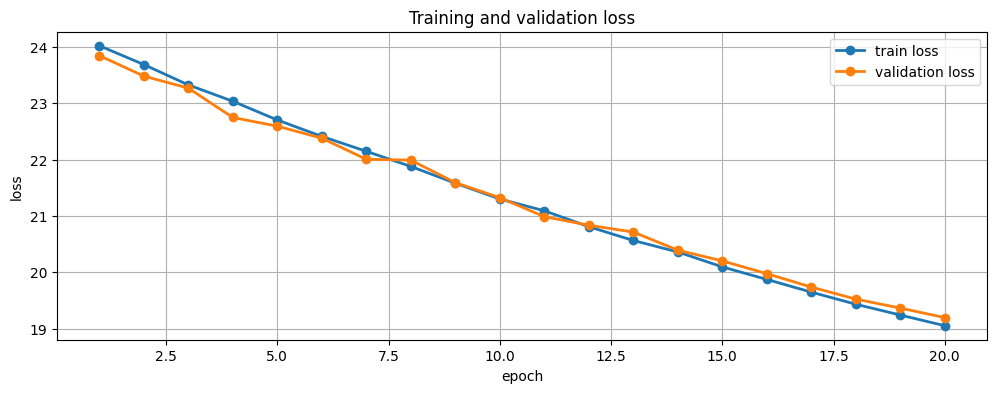

In [22]:
word2vec = Word2Vec(train_filename=train_data, val_filename=val_data, embedding_size=100, tokenizer=tokenizer, batch_size=1000)
train_losses, val_losses = word2vec.train(n_iter=20, lr=0.0001)
viz_losses(train_losses, val_losses)

Let's look on the trained vectors and evaluate how well did they capture words similarity:

In [24]:
print(cosine_similarity(word2vec.get("quantity"), word2vec.get("amount")))
print(cosine_similarity(word2vec.get("summer"), word2vec.get("eat")))

0.08700669625533902
0.053979149863086974
